# Analyse de la décote des produits d'occasion

Marya Khelifa et Nour Bouabid

In [133]:
import pandas as pd
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, r2_score, mean_absolute_error, mean_squared_error
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, KFold
from sklearn.linear_model import Ridge
import matplotlib.pyplot as plt
import numpy as np


In [30]:
df=pd.read_csv('data_final.csv', encoding="utf-8-sig")
df.columns

Index(['etat', 'matiere', 'couleur', 'categorie', 'likes', 'prix',
       'prix_total', 'collection', 'prix_moyen_zara', 'decote'],
      dtype='object')

## I.Analyse descriptive

## II. Analyse non supervisée

In [79]:
df_cluster= df.copy()
df_cluster=df_cluster.drop(columns=['prix_total', 'prix_moyen_zara' ]) 

In [81]:
#Prétraitement des variables
variables_num = ['likes', 'prix', 'decote']
variables_cat = ['etat', 'categorie', 'collection', 'matiere', 'couleur']

preprocessor=ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), variables_num),
        ('cat', OneHotEncoder(handle_unknown='ignore'), variables_cat)
    ]
)


X_prepared = preprocessor.fit_transform(df_cluster)

In [82]:
#Choix du nombre de clusters
inerties = []
silhouettes = []

K_range = range(2,15)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_prepared)
    
    inerties.append(kmeans.inertia_)
    silhouettes.append(silhouette_score(X_prepared, labels))

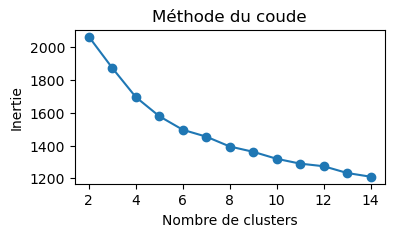

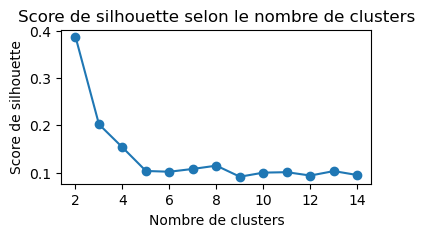

In [83]:
plt.figure(figsize=(4,2))
plt.plot(K_range, inerties, marker='o')
plt.xlabel("Nombre de clusters")
plt.ylabel("Inertie")
plt.title("Méthode du coude")

plt.figure(figsize=(4,2))
plt.plot(K_range, silhouettes, marker='o')
plt.xlabel("Nombre de clusters")
plt.ylabel("Score de silhouette")
plt.title("Score de silhouette selon le nombre de clusters")

plt.show()

In [93]:
k=2
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
df_cluster['cluster'] = kmeans.fit_predict(X_prepared)

print(f"\nNombre de clusters : {k}")
print(f"Score de silhouette : {silhouette_score(X_prepared, labels):.3f}")

moyennes = df_cluster.groupby("cluster")[variables_num].mean()
effectifs = df_cluster.groupby("cluster").size().rename("effectif")
proportions = (effectifs / len(df_cluster) * 100).rename("proportion_%")
resume_clusters = pd.concat([effectifs, proportions, moyennes], axis=1).round(2)

display(resume_clusters)
    



Nombre de clusters : 2
Score de silhouette : 0.387


,effectif,proportion_%,likes,prix,decote
cluster,,,,,
0,337,87.76,21.82,9.77,0.63
1,47,12.24,82.68,44.25,-0.73


In [94]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_prepared.toarray() if hasattr(X_prepared, "toarray") else X_prepared)

df_cluster['ACP1'] = X_pca[:, 0]
df_cluster['ACP2'] = X_pca[:, 1]

In [95]:
print(f"Les deux premiers axes expliquent {pca.explained_variance_ratio_.sum()*100:.2f}% de la variance.")

Les deux premiers axes expliquent 45.07% de la variance.


In [96]:
feature_names = preprocessor.get_feature_names_out()

loadings = pd.DataFrame(
    pca.components_.T,
    index=feature_names,
    columns=['ACP1', 'ACP2']
)

In [103]:
loadings['ACP1'].abs().sort_values(ascending=False).head(5)

num__prix                        0.647417
num__decote                      0.638541
num__likes                       0.316464
cat__etat_neuf avec étiquette    0.103530
cat__collection_fille            0.085884
Name: ACP1, dtype: float64

In [104]:
loadings['ACP2'].sort_values(ascending=True).head(5)

num__prix                                   -0.189980
cat__collection_garçon                      -0.075823
cat__etat_neuf sans étiquette               -0.045742
cat__categorie_sweats et sweats à capuche   -0.025596
cat__couleur_motif/multicolore              -0.021993
Name: ACP2, dtype: float64

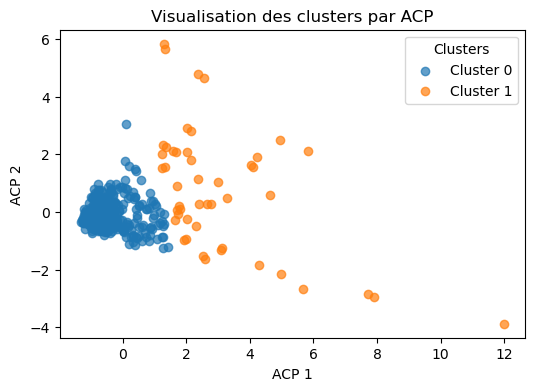

In [99]:
plt.figure(figsize=(6,4))
for cluster in sorted(df_cluster['cluster'].unique()):
    subset = df_cluster[df_cluster['cluster'] == cluster]
    plt.scatter(
        subset['ACP1'],
        subset['ACP2'],
        label=f'Cluster {cluster}',
        alpha=0.7
    )
plt.xlabel("ACP 1")
plt.ylabel("ACP 2")
plt.title("Visualisation des clusters par ACP")
plt.legend(title="Clusters")
plt.show()

# III. Analyse supervisée

In [149]:
df_model=df.copy()
df_model=df_model.drop(columns=['prix_moyen_zara', 'prix_total'])

In [150]:
variables_num = ['likes']
variables_cat = ['etat', 'categorie', 'collection', 'matiere', 'couleur']
X=df_model[variables_num+variables_cat]
y=df_model['decote']


In [151]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [152]:
#Prétraitement des variables
preprocessor=ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), variables_num),
        ('cat', OneHotEncoder(handle_unknown='ignore'), variables_cat)
    ]
)


X_train_prepared = preprocessor.fit_transform(X_train)
X_test_prepared = preprocessor.transform(X_test)

In [ ]:
#Choix de alpha pour regression Ridge
alphas = [0.01, 0.1, 1, 10, 100, 1000]

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

results = {}

for alpha in alphas:
    mse_test = []

    for train_index, test_index in kf.split(X):
        X_tr, X_te = X.iloc[train_index], X.iloc[test_index]
        Y_tr, Y_te = Y.iloc[train_index], Y.iloc[test_index]

        X_tr = preprocessor.fit_transform(X_tr)
        X_te = preprocessor.transform(X_te)

        ridge = Ridge(alpha=alpha)
        ridge.fit(X_tr, Y_tr)

        Y_pred = ridge.predict(X_te)

        mse_test.append(mean_squared_error(Y_te, Y_pred))

    results[alpha] = np.mean(mse_test)

print(results)

{0.01: np.float64(0.3174235029832243), 0.1: np.float64(0.31542896037193113), 1: np.float64(0.3051957325587659), 10: np.float64(0.3047449011585346), 100: np.float64(0.3554334786719089), 1000: np.float64(0.4467255169995609)}


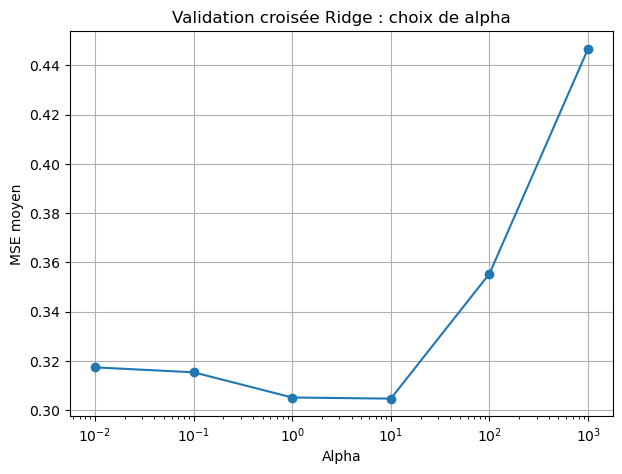

In [137]:
alphas_sorted = sorted(results.keys())
mse_values = [results[alpha] for alpha in alphas_sorted]

plt.figure(figsize=(7, 5))

plt.plot(alphas_sorted, mse_values, marker='o')
plt.xscale('log')
plt.xlabel("Alpha")
plt.ylabel("MSE moyen")
plt.title("Validation croisée Ridge : choix de alpha")
plt.grid(True)

plt.show()

In [156]:
model= Ridge(alpha=10)
model.fit(X_train_prepared, y_train)

,alpha,10
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,None


In [139]:
y_estim = model.predict(X_train_prepared)
y_pred = model.predict(X_test_prepared)

In [163]:
resultats = pd.DataFrame({
    "data": ["Train", "Test"],
    "R2": [
        r2_score(y_train, y_estim),
        r2_score(y_test, y_pred)
    ],

    "RMSE": [
        np.sqrt(mean_squared_error(y_train, y_estim)),
        np.sqrt(mean_squared_error(y_test, y_pred))
    ]
})

resultats

,data,R2,RMSE
0,Train,0.457576,0.512451
1,Test,0.428544,0.514667


In [159]:
feature_names = preprocessor.get_feature_names_out()
len(feature_names)

42

In [157]:
len(model.coef_)

42

In [160]:
feature_names = preprocessor.get_feature_names_out()

coef_df = pd.DataFrame({
    "variable": feature_names,
    "coefficient": model.coef_
})

coef_df["coefficient_abs"] = coef_df["coefficient"].abs()

coef_df = coef_df.sort_values("coefficient_abs", ascending=False)

coef_df.head(15)

,variable,coefficient,coefficient_abs
6,cat__categorie_autres,-0.377667,0.377667
28,cat__matiere_cuir,-0.357168,0.357168
2,cat__etat_neuf avec étiquette,-0.307160,0.307160
7,cat__categorie_blazers et tailleurs,-0.295304,0.295304
24,cat__collection_fille,-0.280197,0.280197
26,cat__collection_homme,0.263539,0.263539
9,cat__categorie_combinaisons et combishorts,-0.181639,0.181639
23,cat__collection_femme,0.170347,0.170347
32,cat__matiere_fibres synthétiques,0.163056,0.163056
25,cat__collection_garçon,-0.153688,0.153688
